# Load Cell PA Capture Workbench

Notebook for viewing single-file `LOAD_CELL_PA_SWEEP_CAPTURE` output from Kalico.

## Usage

1. Run a capture on the printer, for example: `LOAD_CELL_PA_SWEEP_CAPTURE OUTPUT_PATH=/tmp/load_cell_pa_capture`
2. Set `JSON_PATH` below to the generated `.json` file.
3. Run all cells to load the trace, inspect the reported results table, and optionally re-run the minima-based PA analysis on a filtered copy of the force trace.

The notebook uses the serialized capture data directly and keeps the smoothing experiment offline only.


In [11]:
from __future__ import annotations

import json
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import signal

plt.style.use("default")

In [12]:
# Set this to your capture file path
JSON_PATH = Path("../pa_calibrate_20.json")

In [13]:
MIN_PEAK_PTS = 5


def load_pa_capture_json(json_path: Path) -> dict:
    expanded = json_path.expanduser()
    with expanded.open("r", encoding="utf-8") as infile:
        payload = json.load(infile)
    required = {"time", "force", "junctions"}
    missing = sorted(required - payload.keys())
    if missing:
        raise ValueError(
            f"Missing required field(s) in {expanded}: {', '.join(missing)}"
        )
    if len(payload["time"]) != len(payload["force"]):
        raise ValueError("time and force arrays must be the same length")
    return payload


def build_samples_frame(payload: dict) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "sample_index": np.arange(len(payload["time"]), dtype=int),
            "time": pd.to_numeric(payload["time"], errors="coerce"),
            "force_g": pd.to_numeric(payload["force"], errors="coerce"),
        }
    )


def build_junctions_frame(payload: dict) -> pd.DataFrame:
    frame = pd.DataFrame.from_records(payload.get("junctions", []))
    if frame.empty:
        return pd.DataFrame(
            columns=["index", "junction_time", "leg_decel_start"]
        )
    for column in ["index", "junction_time", "leg_decel_start"]:
        if column not in frame:
            raise ValueError(f"Junction record is missing {column!r}")
    frame["index"] = frame["index"].astype(int)
    frame["junction_time"] = pd.to_numeric(
        frame["junction_time"], errors="coerce"
    )
    frame["leg_decel_start"] = pd.to_numeric(
        frame["leg_decel_start"], errors="coerce"
    )
    return frame.sort_values("index").reset_index(drop=True)


def build_fit_results_frame(payload: dict) -> pd.DataFrame:
    frame = pd.DataFrame.from_records(payload.get("fit_results", []))
    if frame.empty:
        return pd.DataFrame()
    numeric_cols = [
        "junction_index",
        "tau",
        "f_init",
        "f_final",
        "elbow_idx",
        "elbow_time",
        "n_transient",
        "n_steady",
        "peak_time",
        "peak_force",
        "trough_time",
        "trough_force",
        "fit_points_used",
    ]
    for column in numeric_cols:
        if column in frame:
            frame[column] = pd.to_numeric(frame[column], errors="coerce")
    if "junction_index" in frame:
        frame["junction_index"] = frame["junction_index"].astype(int)
        frame = frame.sort_values("junction_index").reset_index(drop=True)
    return frame


def build_trapq_moves_frame(payload: dict) -> pd.DataFrame:
    frame = pd.DataFrame.from_records(payload.get("trapq_moves", []))
    if frame.empty:
        return pd.DataFrame()
    numeric_cols = [
        "print_time",
        "move_t",
        "start_v",
        "accel",
        "start_x",
        "start_y",
        "start_z",
        "x_r",
        "y_r",
        "z_r",
    ]
    for column in numeric_cols:
        if column in frame:
            frame[column] = pd.to_numeric(frame[column], errors="coerce")
    return frame.reset_index(drop=True)


def build_results_table(
    junctions: pd.DataFrame,
    fit_results: pd.DataFrame,
) -> pd.DataFrame:
    if junctions.empty and fit_results.empty:
        return pd.DataFrame()
    if junctions.empty:
        return fit_results.copy()
    results = junctions.rename(columns={"index": "junction_index"}).copy()
    results["window_ms"] = (
        results["leg_decel_start"] - results["junction_time"]
    ) * 1000.0
    if fit_results.empty:
        return results
    fit_cols = [
        column
        for column in [
            "junction_index",
            "tau",
            "peak_time",
            "peak_force",
            "f_init",
            "f_final",
            "n_transient",
            "n_steady",
            "trough_time",
            "trough_force",
            "fit_points_used",
        ]
        if column in fit_results.columns
    ]
    results = results.merge(
        fit_results[fit_cols],
        on="junction_index",
        how="left",
    )
    return results.sort_values("junction_index").reset_index(drop=True)


def estimate_sample_frequency_hz(samples: pd.DataFrame) -> float:
    times = samples["time"].dropna().to_numpy(dtype=float)
    deltas = np.diff(times)
    deltas = deltas[np.isfinite(deltas) & (deltas > 0.0)]
    if len(deltas) == 0:
        raise ValueError("Could not estimate sample frequency from time data")
    return float(1.0 / np.median(deltas))


def estimate_sample_interval_s(samples: pd.DataFrame) -> float:
    return float(1.0 / estimate_sample_frequency_hz(samples))


def fit_quadratic_vertex(
    times: np.ndarray,
    forces: np.ndarray,
) -> tuple[np.ndarray, float, float] | None:
    coefficients = np.polyfit(times, forces, 2)
    a, b, _ = coefficients
    if abs(a) < 1e-12 or a <= 0.0:
        return None
    vertex_time = float(-b / (2.0 * a))
    if not float(times[0]) <= vertex_time <= float(times[-1]):
        return None
    vertex_force = float(np.polyval(coefficients, vertex_time))
    return coefficients, vertex_time, vertex_force


def estimate_fit_results(
    samples: pd.DataFrame,
    junctions: pd.DataFrame,
    force_column: str = "force_g",
    subsample_fit_points: int | None = None,
    sensor_delay_samples: float = 0.0,
) -> pd.DataFrame:
    columns = [
        "junction_index",
        "tau",
        "f_init",
        "f_final",
        "elbow_idx",
        "elbow_time",
        "n_transient",
        "n_steady",
        "peak_time",
        "peak_force",
        "trough_time",
        "trough_force",
        "fit_points_used",
    ]
    if force_column not in samples:
        raise ValueError(f"Unknown force column {force_column!r}")
    if subsample_fit_points is not None:
        if subsample_fit_points < 3 or subsample_fit_points % 2 == 0:
            raise ValueError("subsample_fit_points must be an odd integer >= 3")
    if junctions.empty:
        return pd.DataFrame(columns=columns)
    trace = samples.loc[
        samples[force_column].notna(),
        ["sample_index", "time", force_column],
    ].copy()
    sample_interval_s = estimate_sample_interval_s(trace)
    sensor_delay_s = float(sensor_delay_samples) * sample_interval_s
    fit_rows = []
    for row in junctions.itertuples(index=False):
        window = trace[
            (trace["time"] >= row.junction_time)
            & (trace["time"] < row.leg_decel_start)
        ]
        if len(window) < MIN_PEAK_PTS:
            continue
        times = window["time"].to_numpy(dtype=float)
        forces = window[force_column].to_numpy(dtype=float)
        trough_idx = int(np.argmin(forces))
        reversal_idx = trough_idx - 1
        if reversal_idx < 0:
            continue
        peak_time = float(times[reversal_idx])
        peak_force = float(forces[reversal_idx])
        trough_time = float(times[trough_idx])
        trough_force = float(forces[trough_idx])
        fit_points_used = 0
        if subsample_fit_points is not None:
            radius = (subsample_fit_points - 1) // 2
            fit_start = trough_idx - radius
            fit_stop = trough_idx + radius + 1
            if fit_start >= 0 and fit_stop <= len(forces):
                fit = fit_quadratic_vertex(
                    times[fit_start:fit_stop],
                    forces[fit_start:fit_stop],
                )
                if fit is not None:
                    coefficients, trough_time, trough_force = fit
                    sample_delay = float(
                        times[trough_idx] - times[trough_idx - 1]
                    )
                    peak_time = trough_time - sample_delay
                    peak_force = float(np.polyval(coefficients, peak_time))
                    fit_points_used = int(subsample_fit_points)
        corrected_peak_time = peak_time - sensor_delay_s
        corrected_trough_time = trough_time - sensor_delay_s
        tau = corrected_peak_time - float(row.junction_time)
        if tau <= 0.0:
            continue
        n_transient = reversal_idx + 1
        fit_rows.append(
            {
                "junction_index": int(row.index),
                "tau": float(tau),
                "f_init": float(forces[0]),
                "f_final": peak_force,
                "elbow_idx": int(reversal_idx),
                "elbow_time": corrected_peak_time,
                "n_transient": int(n_transient),
                "n_steady": int(max(len(forces) - n_transient, 0)),
                "peak_time": corrected_peak_time,
                "peak_force": peak_force,
                "trough_time": corrected_trough_time,
                "trough_force": trough_force,
                "fit_points_used": int(fit_points_used),
            }
        )
    if not fit_rows:
        return pd.DataFrame(columns=columns)
    return pd.DataFrame.from_records(fit_rows)[columns]


def apply_zero_phase_lowpass_filter(
    samples: pd.DataFrame,
    cutoff_hz: float,
    order: int = 2,
    force_column: str = "force_g",
    filtered_column: str = "force_filtered_g",
) -> tuple[pd.DataFrame, np.ndarray, float]:
    if order < 1:
        raise ValueError("Filter order must be at least 1")
    sample_frequency_hz = estimate_sample_frequency_hz(samples)
    nyquist_hz = sample_frequency_hz / 2.0
    if not 0.0 < cutoff_hz < nyquist_hz:
        raise ValueError(
            f"cutoff_hz must be between 0 and Nyquist ({nyquist_hz:.2f} Hz)"
        )
    valid_mask = samples[force_column].notna()
    force = samples.loc[valid_mask, force_column].to_numpy(dtype=float)
    if len(force) < MIN_PEAK_PTS:
        raise ValueError("Not enough valid force samples to filter")
    sos = signal.butter(
        order,
        cutoff_hz,
        btype="lowpass",
        fs=sample_frequency_hz,
        output="sos",
    )
    padlen = max(0, min(len(force) - 1, 3 * (2 * len(sos) + 1)))
    filtered_force = signal.sosfiltfilt(sos, force, padlen=padlen)
    filtered_samples = samples.copy()
    filtered_samples[filtered_column] = np.nan
    filtered_samples.loc[valid_mask, filtered_column] = filtered_force
    return filtered_samples, sos, sample_frequency_hz


def apply_savgol_filter(
    samples: pd.DataFrame,
    window_length: int,
    polyorder: int,
    force_column: str = "force_g",
    filtered_column: str = "force_filtered_g",
) -> pd.DataFrame:
    if window_length < 3 or window_length % 2 == 0:
        raise ValueError("window_length must be an odd integer >= 3")
    if polyorder < 0 or polyorder >= window_length:
        raise ValueError(
            "polyorder must be >= 0 and smaller than window_length"
        )
    valid_mask = samples[force_column].notna()
    force = samples.loc[valid_mask, force_column].to_numpy(dtype=float)
    if len(force) < window_length:
        raise ValueError(
            f"Need at least {window_length} valid samples for Savitzky-Golay"
        )
    filtered_force = signal.savgol_filter(
        force,
        window_length=window_length,
        polyorder=polyorder,
        mode="interp",
    )
    filtered_samples = samples.copy()
    filtered_samples[filtered_column] = np.nan
    filtered_samples.loc[valid_mask, filtered_column] = filtered_force
    return filtered_samples


def summarize_fit_results(
    label: str,
    fit_results: pd.DataFrame,
) -> dict[str, str | int | float]:
    summary: dict[str, str | int | float] = {
        "analysis": label,
        "junction_count": 0,
        "mean_tau_ms": np.nan,
        "std_tau_ms": np.nan,
        "min_tau_ms": np.nan,
        "max_tau_ms": np.nan,
    }
    if fit_results.empty or "tau" not in fit_results:
        return summary
    taus_ms = fit_results["tau"].dropna().to_numpy(dtype=float) * 1000.0
    if len(taus_ms) == 0:
        return summary
    summary.update(
        {
            "junction_count": int(len(taus_ms)),
            "mean_tau_ms": float(np.mean(taus_ms)),
            "std_tau_ms": float(np.std(taus_ms, ddof=0)),
            "min_tau_ms": float(np.min(taus_ms)),
            "max_tau_ms": float(np.max(taus_ms)),
        }
    )
    return summary


def build_summary_frame(named_results: dict[str, pd.DataFrame]) -> pd.DataFrame:
    frame = pd.DataFrame(
        [
            summarize_fit_results(label, fit_frame)
            for label, fit_frame in named_results.items()
        ]
    )
    return frame


def build_fit_comparison_frame(
    raw_fit_results: pd.DataFrame,
    filtered_fit_results: pd.DataFrame,
) -> pd.DataFrame:
    raw = raw_fit_results.rename(
        columns={
            "tau": "raw_tau",
            "peak_time": "raw_peak_time",
            "peak_force": "raw_peak_force",
        }
    )
    filtered = filtered_fit_results.rename(
        columns={
            "tau": "filtered_tau",
            "peak_time": "filtered_peak_time",
            "peak_force": "filtered_peak_force",
        }
    )
    raw_cols = [
        column
        for column in [
            "junction_index",
            "raw_tau",
            "raw_peak_time",
            "raw_peak_force",
        ]
        if column in raw.columns
    ]
    filtered_cols = [
        column
        for column in [
            "junction_index",
            "filtered_tau",
            "filtered_peak_time",
            "filtered_peak_force",
        ]
        if column in filtered.columns
    ]
    if not raw_cols and not filtered_cols:
        return pd.DataFrame()
    if not raw_cols:
        comparison = filtered[filtered_cols].copy()
    elif not filtered_cols:
        comparison = raw[raw_cols].copy()
    else:
        comparison = raw[raw_cols].merge(
            filtered[filtered_cols],
            on="junction_index",
            how="outer",
        )
    comparison = comparison.sort_values("junction_index").reset_index(drop=True)
    if "raw_tau" in comparison:
        comparison["raw_tau_ms"] = comparison["raw_tau"] * 1000.0
    if "filtered_tau" in comparison:
        comparison["filtered_tau_ms"] = comparison["filtered_tau"] * 1000.0
    if {
        "raw_tau_ms",
        "filtered_tau_ms",
    }.issubset(comparison.columns):
        comparison["tau_delta_ms"] = (
            comparison["filtered_tau_ms"] - comparison["raw_tau_ms"]
        )
    if {
        "raw_peak_force",
        "filtered_peak_force",
    }.issubset(comparison.columns):
        comparison["peak_force_delta_g"] = (
            comparison["filtered_peak_force"] - comparison["raw_peak_force"]
        )
    return comparison


def build_named_fit_comparison_frame(
    named_fit_results: dict[str, pd.DataFrame],
) -> pd.DataFrame:
    comparison: pd.DataFrame | None = None
    for label, fit_results in named_fit_results.items():
        if fit_results.empty:
            continue
        prefix = re.sub(r"[^a-z0-9]+", "_", label.lower()).strip("_")
        subset = fit_results[
            [
                column
                for column in [
                    "junction_index",
                    "tau",
                    "peak_time",
                    "peak_force",
                    "trough_time",
                    "trough_force",
                    "fit_points_used",
                ]
                if column in fit_results.columns
            ]
        ].copy()
        rename_map = {}
        if "tau" in subset:
            subset[f"{prefix}_tau_ms"] = subset["tau"] * 1000.0
            rename_map["peak_time"] = f"{prefix}_peak_time"
            rename_map["peak_force"] = f"{prefix}_peak_force"
            rename_map["trough_time"] = f"{prefix}_trough_time"
            rename_map["trough_force"] = f"{prefix}_trough_force"
            rename_map["fit_points_used"] = f"{prefix}_fit_points_used"
            subset = subset.drop(columns=["tau"])
        subset = subset.rename(columns=rename_map)
        if comparison is None:
            comparison = subset
        else:
            comparison = comparison.merge(
                subset, on="junction_index", how="outer"
            )
    if comparison is None:
        return pd.DataFrame()
    return comparison.sort_values("junction_index").reset_index(drop=True)


def max_abs_tau_diff_ms(
    left_fit_results: pd.DataFrame,
    right_fit_results: pd.DataFrame,
) -> float | None:
    required = {"junction_index", "tau"}
    if left_fit_results.empty or right_fit_results.empty:
        return None
    if not required.issubset(left_fit_results.columns):
        return None
    if not required.issubset(right_fit_results.columns):
        return None
    merged = left_fit_results[["junction_index", "tau"]].merge(
        right_fit_results[["junction_index", "tau"]],
        on="junction_index",
        suffixes=("_left", "_right"),
        how="inner",
    )
    if merged.empty:
        return None
    deltas_ms = np.abs(merged["tau_left"] - merged["tau_right"]) * 1000.0
    return float(deltas_ms.max())


def sweep_zero_phase_lowpass_cutoffs(
    samples: pd.DataFrame,
    junctions: pd.DataFrame,
    cutoffs_hz: list[float],
    order: int = 2,
    sensor_delay_samples: float = 0.0,
) -> pd.DataFrame:
    rows = []
    for cutoff_hz in cutoffs_hz:
        filtered_samples, _, _ = apply_zero_phase_lowpass_filter(
            samples,
            cutoff_hz=cutoff_hz,
            order=order,
        )
        filtered_fit_results = estimate_fit_results(
            filtered_samples,
            junctions,
            force_column="force_filtered_g",
            sensor_delay_samples=sensor_delay_samples,
        )
        row = summarize_fit_results(
            f"low-pass {cutoff_hz:.1f} Hz",
            filtered_fit_results,
        )
        row["cutoff_hz"] = float(cutoff_hz)
        rows.append(row)
    if not rows:
        return pd.DataFrame()
    sweep = pd.DataFrame(rows)
    return sweep.sort_values("cutoff_hz").reset_index(drop=True)


def sweep_savgol_window_lengths(
    samples: pd.DataFrame,
    junctions: pd.DataFrame,
    window_lengths: list[int],
    polyorder: int = 3,
    sensor_delay_samples: float = 0.0,
) -> pd.DataFrame:
    rows = []
    for window_length in window_lengths:
        filtered_samples = apply_savgol_filter(
            samples,
            window_length=window_length,
            polyorder=polyorder,
        )
        filtered_fit_results = estimate_fit_results(
            filtered_samples,
            junctions,
            force_column="force_filtered_g",
            sensor_delay_samples=sensor_delay_samples,
        )
        row = summarize_fit_results(
            f"Savitzky-Golay {window_length} samples",
            filtered_fit_results,
        )
        row["window_length"] = int(window_length)
        row["polyorder"] = int(polyorder)
        rows.append(row)
    if not rows:
        return pd.DataFrame()
    sweep = pd.DataFrame(rows)
    return sweep.sort_values("window_length").reset_index(drop=True)

In [14]:
payload = load_pa_capture_json(JSON_PATH)
samples = build_samples_frame(payload)
junctions = build_junctions_frame(payload)
fit_results = build_fit_results_frame(payload)
trapq_moves = build_trapq_moves_frame(payload)
results_table = build_results_table(junctions, fit_results)

sample_count = len(samples)
valid_force_count = int(samples["force_g"].notna().sum())
time_min = samples["time"].min(skipna=True)
time_max = samples["time"].max(skipna=True)

print(f"Loaded {sample_count:,} samples from {JSON_PATH}")
print(f"Valid force samples: {valid_force_count:,}")
print(f"Trace span: {time_min:.4f}s to {time_max:.4f}s")
print(f"Junctions: {len(junctions)}")
print(f"Trapq moves: {len(trapq_moves)}")
print(f"Reported fit_results: {len(fit_results)}")
if not fit_results.empty:
    print(
        "Reported avg PA time: "
        f"{fit_results['tau'].mean():.4f}s +/- {fit_results['tau'].std(ddof=0):.4f}s"
    )
if not results_table.empty:
    display(results_table)
else:
    print("No reported results found in the capture file.")

Loaded 2,776 samples from ../pa_calibrate_20.json
Valid force samples: 2,776
Trace span: 0.0012s to 8.1800s
Junctions: 10
Trapq moves: 43
Reported fit_results: 10
Reported avg PA time: 0.0194s +/- 0.0010s


,junction_index,junction_time,leg_decel_start,window_ms,tau,peak_time,peak_force,f_init,f_final,n_transient,n_steady
0,0,0.745393,1.408723,663.330000,0.020845,0.767712,2276.537968,2487.836799,2276.537968,8,217
1,1,1.487366,2.150696,663.330000,0.018275,1.507115,2318.893275,2503.501975,2318.893275,7,218
2,2,2.229339,2.892669,663.330000,0.018912,2.249725,2323.650823,2494.204565,2323.650823,7,218
3,3,2.971312,3.634642,663.330000,0.019876,2.992662,2311.037244,2523.524665,2311.037244,8,217
4,4,3.713285,4.376615,663.330000,0.020574,3.735333,2258.168621,2445.725181,2258.168621,8,217
5,5,4.455258,5.118588,663.330000,0.017900,4.474632,2310.656192,2489.129355,2310.656192,7,218
6,6,5.197232,5.860562,663.330000,0.018926,5.217632,2359.946054,2522.080783,2359.946054,7,218
7,7,5.939205,6.602535,663.330000,0.019672,5.960351,2374.517465,2585.390751,2374.517465,8,217
8,8,6.681178,7.344508,663.330000,0.020584,6.703236,2358.516760,2559.455343,2358.516760,8,217
9,9,7.423152,8.086400,663.248333,0.018617,7.443243,2395.279419,2570.001075,2395.279419,7,218


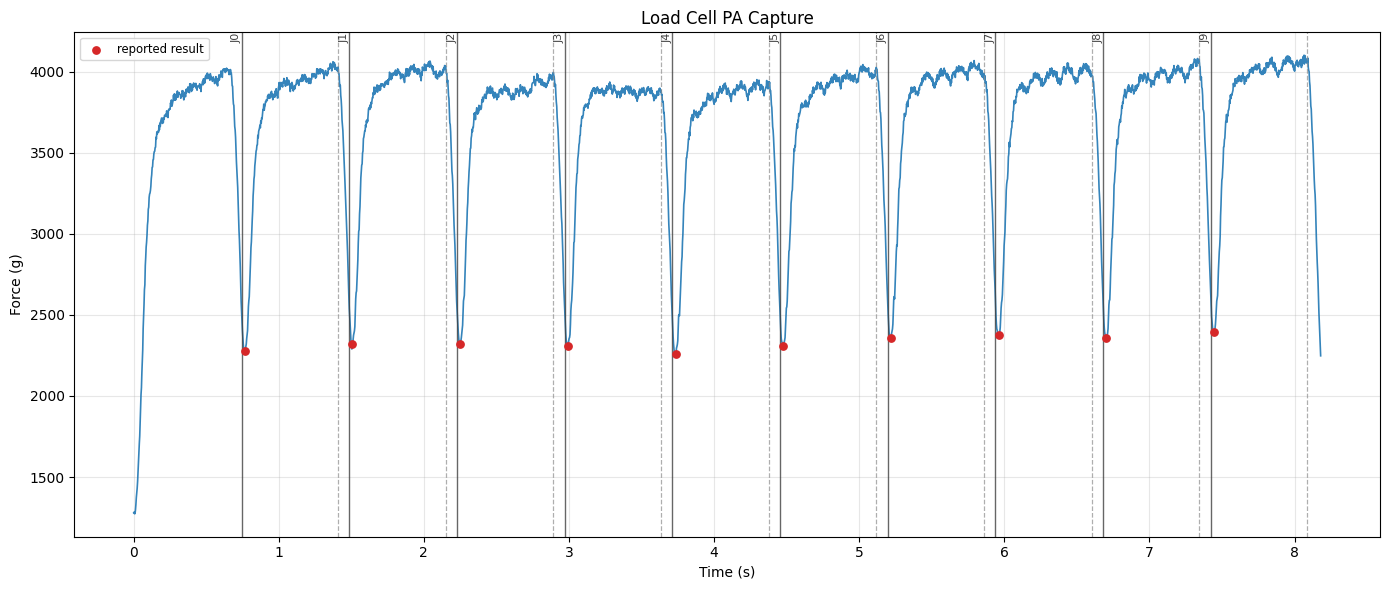

In [15]:
def plot_force_trace(
    samples: pd.DataFrame,
    junctions: pd.DataFrame,
    fit_results: pd.DataFrame | None = None,
):
    fig, ax = plt.subplots(figsize=(14, 6))
    trace = samples[samples["force_g"].notna()]
    ax.plot(
        trace["time"],
        trace["force_g"],
        color="tab:blue",
        linewidth=1.2,
        alpha=0.9,
    )
    _, ymax = ax.get_ylim()
    for row in junctions.itertuples(index=False):
        ax.axvline(
            row.junction_time,
            color="0.25",
            linestyle="-",
            linewidth=1.0,
            alpha=0.8,
        )
        ax.axvline(
            row.leg_decel_start,
            color="0.55",
            linestyle="--",
            linewidth=0.9,
            alpha=0.7,
        )
        ax.text(
            row.junction_time,
            ymax,
            f"J{row.index}",
            rotation=90,
            va="top",
            ha="right",
            fontsize=8,
            color="0.25",
        )
    if fit_results is not None and not fit_results.empty:
        ax.scatter(
            fit_results["peak_time"],
            fit_results["peak_force"],
            color="tab:red",
            s=28,
            label="reported result",
            zorder=4,
        )
    ax.set_title("Load Cell PA Capture")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Force (g)")
    ax.grid(True, alpha=0.3)
    if fit_results is not None and not fit_results.empty:
        ax.legend(loc="best", fontsize="small")
    fig.tight_layout()
    return fig, ax


plot_force_trace(samples, junctions, fit_results)
plt.show()

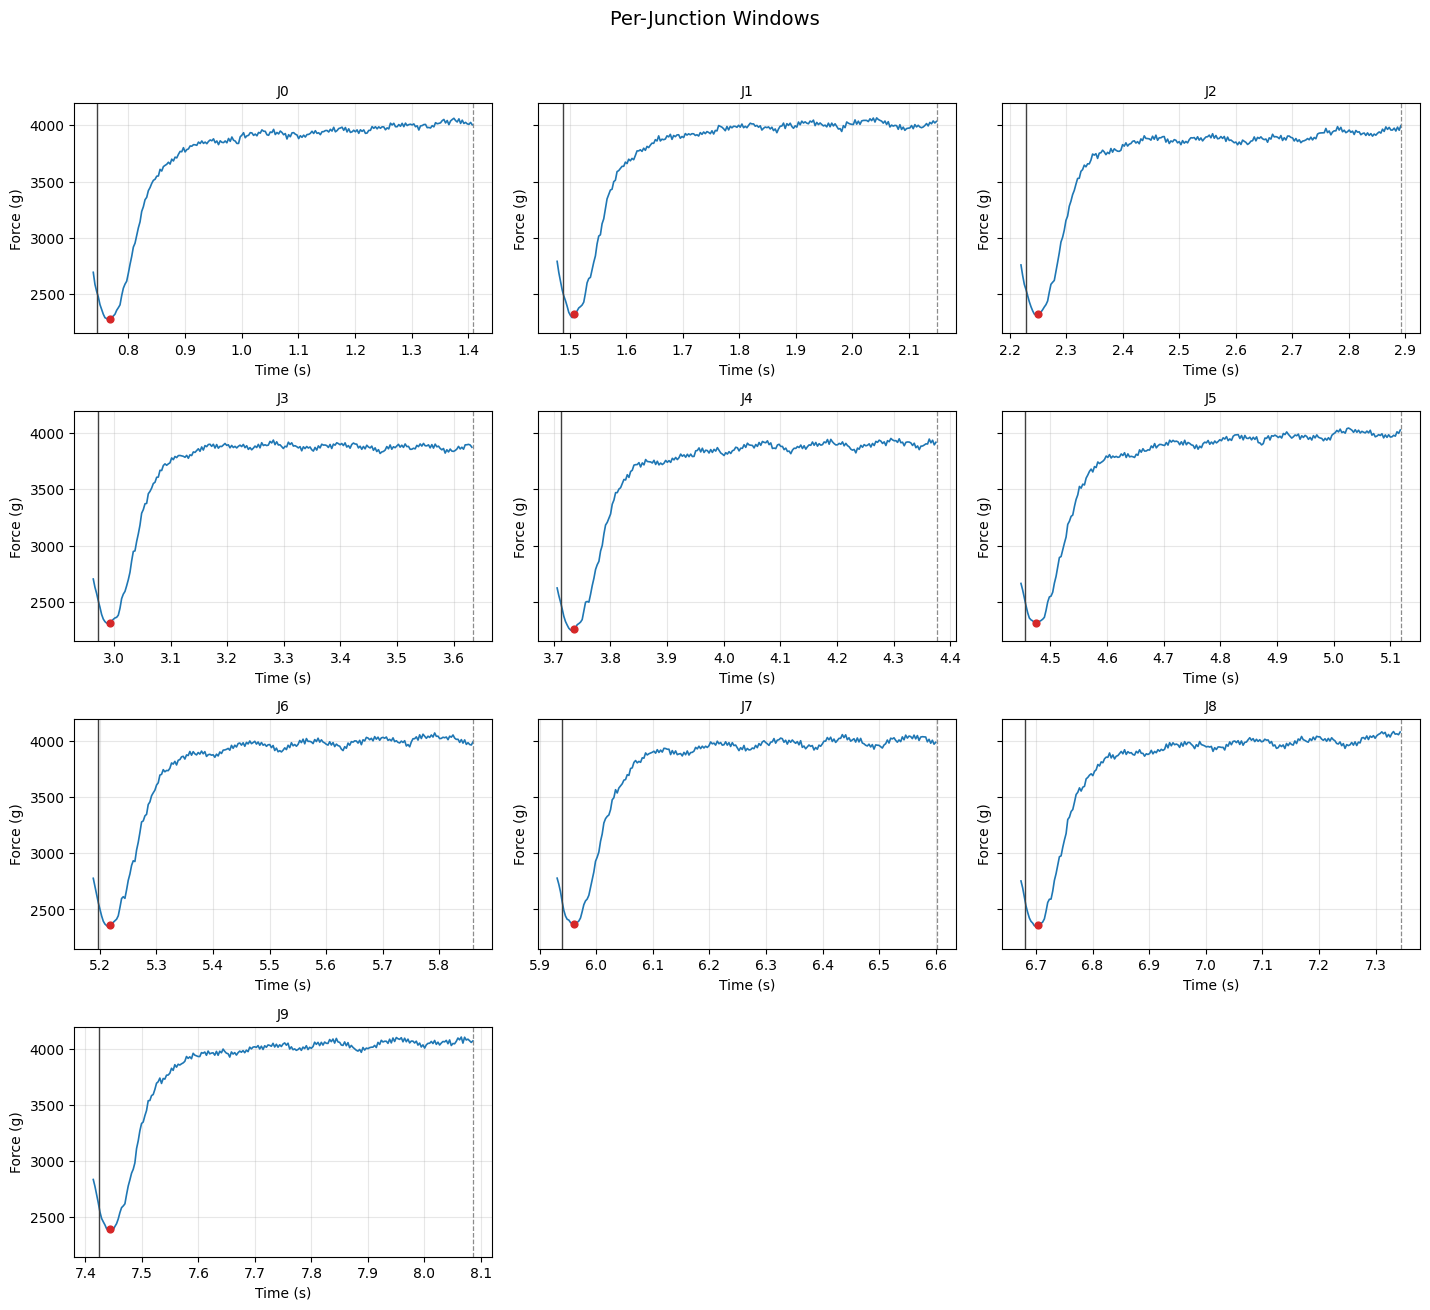

In [16]:
def plot_junction_windows(
    samples: pd.DataFrame,
    junctions: pd.DataFrame,
    fit_results: pd.DataFrame | None = None,
    columns: int = 3,
    pre_window: float = 0.01,
):
    if junctions.empty:
        raise ValueError("No junctions available")
    rows = math.ceil(len(junctions) / columns)
    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(4.8 * columns, 3.2 * rows),
        sharey=True,
        squeeze=False,
    )
    trace = samples[samples["force_g"].notna()]
    fit_lookup = {}
    if fit_results is not None and not fit_results.empty:
        fit_lookup = {
            int(row.junction_index): row
            for row in fit_results.itertuples(index=False)
        }
    axes_flat = axes.ravel()
    for ax, row in zip(axes_flat, junctions.itertuples(index=False)):
        start = max(trace["time"].min(), row.junction_time - pre_window)
        stop = row.leg_decel_start
        window = trace[(trace["time"] >= start) & (trace["time"] <= stop)]
        ax.plot(
            window["time"], window["force_g"], color="tab:blue", linewidth=1.2
        )
        ax.axvline(row.junction_time, color="0.25", linewidth=1.0)
        ax.axvline(
            row.leg_decel_start, color="0.55", linestyle="--", linewidth=0.9
        )
        fit_row = fit_lookup.get(int(row.index))
        if fit_row is not None:
            ax.scatter(
                [fit_row.peak_time],
                [fit_row.peak_force],
                color="tab:red",
                s=24,
                zorder=4,
            )
        ax.set_title(f"J{row.index}", fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Force (g)")
    for ax in axes_flat[len(junctions) :]:
        ax.axis("off")
    fig.suptitle("Per-Junction Windows", fontsize=14, y=1.02)
    fig.tight_layout()
    return fig, axes


plot_junction_windows(samples, junctions, fit_results)
plt.show()

## Offline Smoothing Experiment

This section keeps the zero-phase Butterworth low-pass baseline, then adds a Savitzky-Golay pass and re-runs the same minima-based PA estimate on the smoothed trace.

Savitzky-Golay is useful here because it often preserves the local shape of a trough better than a conventional low-pass filter, which makes it a good next experiment before moving on to sub-sample minimum fitting.


In [17]:
def plot_force_trace_comparison(
    samples: pd.DataFrame,
    junctions: pd.DataFrame,
    raw_fit_results: pd.DataFrame,
    filtered_fit_results: pd.DataFrame,
    filtered_column: str = "force_filtered_g",
    filtered_label: str = "filtered force",
    plot_title: str = "Raw vs Filtered Force Trace",
):
    fig, ax = plt.subplots(figsize=(14, 6))
    raw_trace = samples[samples["force_g"].notna()]
    filtered_trace = samples[samples[filtered_column].notna()]
    ax.plot(
        raw_trace["time"],
        raw_trace["force_g"],
        color="tab:blue",
        linewidth=1.0,
        alpha=0.35,
        label="raw force",
    )
    ax.plot(
        filtered_trace["time"],
        filtered_trace[filtered_column],
        color="tab:orange",
        linewidth=1.4,
        alpha=0.95,
        label=filtered_label,
    )
    for row in junctions.itertuples(index=False):
        ax.axvline(
            row.junction_time,
            color="0.30",
            linestyle="-",
            linewidth=0.8,
            alpha=0.5,
        )
        ax.axvline(
            row.leg_decel_start,
            color="0.55",
            linestyle="--",
            linewidth=0.8,
            alpha=0.4,
        )
    if not raw_fit_results.empty:
        ax.scatter(
            raw_fit_results["peak_time"],
            raw_fit_results["peak_force"],
            color="tab:blue",
            s=22,
            alpha=0.9,
            label="raw minima",
            zorder=4,
        )
    if not filtered_fit_results.empty:
        ax.scatter(
            filtered_fit_results["peak_time"],
            filtered_fit_results["peak_force"],
            color="tab:orange",
            edgecolor="black",
            linewidth=0.4,
            s=28,
            alpha=0.95,
            label="smoothed minima",
            zorder=5,
        )
    ax.set_title(plot_title)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Force (g)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize="small")
    fig.tight_layout()
    return fig, ax


def plot_junction_window_comparison(
    samples: pd.DataFrame,
    junctions: pd.DataFrame,
    raw_fit_results: pd.DataFrame,
    filtered_fit_results: pd.DataFrame,
    filtered_column: str = "force_filtered_g",
    filtered_label: str = "filtered",
    plot_title: str = "Per-Junction Raw vs Filtered Windows",
    columns: int = 3,
    pre_window: float = 0.01,
):
    if junctions.empty:
        raise ValueError("No junctions available")
    rows = math.ceil(len(junctions) / columns)
    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(4.8 * columns, 3.4 * rows),
        sharey=True,
        squeeze=False,
    )
    trace = samples[
        samples["force_g"].notna() & samples[filtered_column].notna()
    ]
    raw_lookup = {
        int(row.junction_index): row
        for row in raw_fit_results.itertuples(index=False)
    }
    filtered_lookup = {
        int(row.junction_index): row
        for row in filtered_fit_results.itertuples(index=False)
    }
    axes_flat = axes.ravel()
    for ax, row in zip(axes_flat, junctions.itertuples(index=False)):
        start = max(trace["time"].min(), row.junction_time - pre_window)
        stop = row.leg_decel_start
        window = trace[(trace["time"] >= start) & (trace["time"] <= stop)]
        ax.plot(
            window["time"],
            window["force_g"],
            color="tab:blue",
            linewidth=1.0,
            alpha=0.35,
            label="raw",
        )
        ax.plot(
            window["time"],
            window[filtered_column],
            color="tab:orange",
            linewidth=1.3,
            alpha=0.95,
            label=filtered_label,
        )
        ax.axvline(row.junction_time, color="0.30", linewidth=0.9)
        ax.axvline(
            row.leg_decel_start,
            color="0.55",
            linestyle="--",
            linewidth=0.9,
        )
        raw_row = raw_lookup.get(int(row.index))
        if raw_row is not None:
            ax.scatter(
                [raw_row.peak_time],
                [raw_row.peak_force],
                color="tab:blue",
                s=24,
                zorder=4,
            )
        filtered_row = filtered_lookup.get(int(row.index))
        if filtered_row is not None:
            ax.scatter(
                [filtered_row.peak_time],
                [filtered_row.peak_force],
                color="tab:orange",
                edgecolor="black",
                linewidth=0.4,
                s=28,
                zorder=5,
            )
        ax.set_title(f"J{row.index}", fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Force (g)")
    handles, labels = axes_flat[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper right")
    for ax in axes_flat[len(junctions) :]:
        ax.axis("off")
    fig.suptitle(plot_title, fontsize=14, y=1.02)
    fig.tight_layout()
    return fig, axes


def plot_cutoff_sweep(
    cutoff_sweep: pd.DataFrame,
    raw_std_tau_ms: float | None = None,
):
    if cutoff_sweep.empty:
        raise ValueError("No cutoff sweep data available")
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(
        cutoff_sweep["cutoff_hz"],
        cutoff_sweep["std_tau_ms"],
        marker="o",
        color="tab:orange",
        linewidth=1.4,
    )
    if raw_std_tau_ms is not None and np.isfinite(raw_std_tau_ms):
        ax.axhline(
            raw_std_tau_ms,
            color="tab:blue",
            linestyle="--",
            linewidth=1.0,
            label="raw std",
        )
    best_row = cutoff_sweep.loc[cutoff_sweep["std_tau_ms"].idxmin()]
    ax.scatter(
        [best_row["cutoff_hz"]],
        [best_row["std_tau_ms"]],
        color="tab:red",
        s=36,
        zorder=4,
        label="best cutoff",
    )
    ax.set_title("Butterworth Tau Std Dev vs Cutoff")
    ax.set_xlabel("Low-pass cutoff (Hz)")
    ax.set_ylabel("Std dev of tau (ms)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize="small")
    fig.tight_layout()
    return fig, ax


def plot_savgol_window_sweep(
    savgol_sweep: pd.DataFrame,
    raw_std_tau_ms: float | None = None,
):
    if savgol_sweep.empty:
        raise ValueError("No Savitzky-Golay sweep data available")
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(
        savgol_sweep["window_length"],
        savgol_sweep["std_tau_ms"],
        marker="o",
        color="tab:green",
        linewidth=1.4,
    )
    if raw_std_tau_ms is not None and np.isfinite(raw_std_tau_ms):
        ax.axhline(
            raw_std_tau_ms,
            color="tab:blue",
            linestyle="--",
            linewidth=1.0,
            label="raw std",
        )
    best_row = savgol_sweep.loc[savgol_sweep["std_tau_ms"].idxmin()]
    ax.scatter(
        [best_row["window_length"]],
        [best_row["std_tau_ms"]],
        color="tab:red",
        s=36,
        zorder=4,
        label="best window",
    )
    ax.set_title("Savitzky-Golay Tau Std Dev vs Window Length")
    ax.set_xlabel("Window length (samples)")
    ax.set_ylabel("Std dev of tau (ms)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize="small")
    fig.tight_layout()
    return fig, ax


def plot_tau_by_junction(
    comparison: pd.DataFrame,
    tau_columns: list[tuple[str, str]],
    plot_title: str = "Tau by Junction",
):
    if comparison.empty:
        raise ValueError("No comparison data available")
    fig, ax = plt.subplots(figsize=(10, 4.5))
    for label, column in tau_columns:
        if column not in comparison:
            continue
        ax.plot(
            comparison["junction_index"],
            comparison[column],
            marker="o",
            linewidth=1.3,
            label=label,
        )
    ax.set_title(plot_title)
    ax.set_xlabel("Junction Index")
    ax.set_ylabel("Tau (ms)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize="small")
    fig.tight_layout()
    return fig, ax

In [18]:
LOWPASS_ORDER = 2
SELECTED_CUTOFF_HZ = 20.0
CANDIDATE_CUTOFFS_HZ = [10.0, 15.0, 20.0, 25.0, 30.0, 35.0, 40.0, 50.0, 60.0]
SELECTED_SAVGOL_WINDOW_LENGTH = 25
SELECTED_SAVGOL_POLYORDER = 3
CANDIDATE_SAVGOL_WINDOW_LENGTHS = [9, 11, 13, 15, 17, 21, 25, 31]
SUBSAMPLE_FIT_POINTS_OPTIONS = [3, 5]
SENSOR_DELAY_SAMPLES = 0.5
COMPARISON_PRE_WINDOW_S = 0.01

sample_frequency_hz = estimate_sample_frequency_hz(samples)
sample_interval_s = estimate_sample_interval_s(samples)
sensor_delay_ms = SENSOR_DELAY_SAMPLES * sample_interval_s * 1000.0
raw_unadjusted_fit_results = estimate_fit_results(samples, junctions)
raw_recomputed_fit_results = estimate_fit_results(
    samples,
    junctions,
    sensor_delay_samples=SENSOR_DELAY_SAMPLES,
)
lowpass_samples, smoothing_sos, _ = apply_zero_phase_lowpass_filter(
    samples,
    cutoff_hz=SELECTED_CUTOFF_HZ,
    order=LOWPASS_ORDER,
)
lowpass_fit_results = estimate_fit_results(
    lowpass_samples,
    junctions,
    force_column="force_filtered_g",
    sensor_delay_samples=SENSOR_DELAY_SAMPLES,
)
savgol_samples = apply_savgol_filter(
    samples,
    window_length=SELECTED_SAVGOL_WINDOW_LENGTH,
    polyorder=SELECTED_SAVGOL_POLYORDER,
)
savgol_fit_results = estimate_fit_results(
    savgol_samples,
    junctions,
    force_column="force_filtered_g",
    sensor_delay_samples=SENSOR_DELAY_SAMPLES,
)
savgol_quad3_fit_results = estimate_fit_results(
    savgol_samples,
    junctions,
    force_column="force_filtered_g",
    subsample_fit_points=3,
    sensor_delay_samples=SENSOR_DELAY_SAMPLES,
)
savgol_quad5_fit_results = estimate_fit_results(
    savgol_samples,
    junctions,
    force_column="force_filtered_g",
    subsample_fit_points=5,
    sensor_delay_samples=SENSOR_DELAY_SAMPLES,
)
analysis_summary = build_summary_frame(
    {
        "reported": fit_results,
        (
            f"raw recomputed (-{SENSOR_DELAY_SAMPLES:.2f} samples)"
        ): raw_recomputed_fit_results,
        f"Butterworth {SELECTED_CUTOFF_HZ:.1f} Hz": lowpass_fit_results,
        (
            "Savitzky-Golay "
            f"{SELECTED_SAVGOL_WINDOW_LENGTH} samples / poly {SELECTED_SAVGOL_POLYORDER}"
        ): savgol_fit_results,
        "Savitzky-Golay + quadratic 3-point": savgol_quad3_fit_results,
        "Savitzky-Golay + quadratic 5-point": savgol_quad5_fit_results,
    }
)
fit_comparison = build_named_fit_comparison_frame(
    {
        "raw": raw_recomputed_fit_results,
        "savgol_discrete": savgol_fit_results,
        "savgol_quad3": savgol_quad3_fit_results,
        "savgol_quad5": savgol_quad5_fit_results,
    }
)
cutoff_sweep = sweep_zero_phase_lowpass_cutoffs(
    samples,
    junctions,
    cutoffs_hz=CANDIDATE_CUTOFFS_HZ,
    order=LOWPASS_ORDER,
    sensor_delay_samples=SENSOR_DELAY_SAMPLES,
)
savgol_window_sweep = sweep_savgol_window_lengths(
    samples,
    junctions,
    window_lengths=CANDIDATE_SAVGOL_WINDOW_LENGTHS,
    polyorder=SELECTED_SAVGOL_POLYORDER,
    sensor_delay_samples=SENSOR_DELAY_SAMPLES,
)
reported_vs_raw_diff_ms = max_abs_tau_diff_ms(
    fit_results,
    raw_unadjusted_fit_results,
)
raw_summary = summarize_fit_results("raw", raw_recomputed_fit_results)
lowpass_summary = summarize_fit_results(
    f"Butterworth {SELECTED_CUTOFF_HZ:.1f} Hz",
    lowpass_fit_results,
)
savgol_summary = summarize_fit_results(
    (
        "Savitzky-Golay "
        f"{SELECTED_SAVGOL_WINDOW_LENGTH} samples / poly {SELECTED_SAVGOL_POLYORDER}"
    ),
    savgol_fit_results,
)
quad3_summary = summarize_fit_results(
    "Savitzky-Golay + quadratic 3-point",
    savgol_quad3_fit_results,
)
quad5_summary = summarize_fit_results(
    "Savitzky-Golay + quadratic 5-point",
    savgol_quad5_fit_results,
)

print(f"Estimated sample frequency: {sample_frequency_hz:.2f} Hz")
print(f"Estimated sample interval: {sample_interval_s * 1000.0:.3f} ms")
print(
    "Applied sensor delay correction: "
    f"-{SENSOR_DELAY_SAMPLES:.2f} samples ({sensor_delay_ms:.3f} ms)"
)
print(
    "Butterworth baseline: "
    f"order={LOWPASS_ORDER}, cutoff={SELECTED_CUTOFF_HZ:.1f} Hz"
)
print(
    "Selected Savitzky-Golay: "
    f"window={SELECTED_SAVGOL_WINDOW_LENGTH}, polyorder={SELECTED_SAVGOL_POLYORDER}"
)
print(
    "Sub-sample quadratic fits: "
    f"{', '.join(str(points) for points in SUBSAMPLE_FIT_POINTS_OPTIONS)} points"
)
if reported_vs_raw_diff_ms is not None:
    print(
        "Reported vs raw recomputed max |tau| delta: "
        f"{reported_vs_raw_diff_ms:.4f} ms"
    )
if np.isfinite(raw_summary["std_tau_ms"]) and np.isfinite(
    lowpass_summary["std_tau_ms"]
):
    print(
        "Butterworth std dev change: "
        f"{lowpass_summary['std_tau_ms'] - raw_summary['std_tau_ms']:+.3f} ms"
    )
if np.isfinite(raw_summary["std_tau_ms"]) and np.isfinite(
    savgol_summary["std_tau_ms"]
):
    print(
        "Savitzky-Golay std dev change: "
        f"{savgol_summary['std_tau_ms'] - raw_summary['std_tau_ms']:+.3f} ms"
    )
if np.isfinite(raw_summary["std_tau_ms"]) and np.isfinite(
    quad3_summary["std_tau_ms"]
):
    print(
        "Savitzky-Golay + quadratic 3-point std dev change: "
        f"{quad3_summary['std_tau_ms'] - raw_summary['std_tau_ms']:+.3f} ms"
    )
if np.isfinite(raw_summary["std_tau_ms"]) and np.isfinite(
    quad5_summary["std_tau_ms"]
):
    print(
        "Savitzky-Golay + quadratic 5-point std dev change: "
        f"{quad5_summary['std_tau_ms'] - raw_summary['std_tau_ms']:+.3f} ms"
    )
if not cutoff_sweep.empty:
    best_row = cutoff_sweep.loc[cutoff_sweep["std_tau_ms"].idxmin()]
    print(
        "Best Butterworth cutoff in sweep: "
        f"{best_row['cutoff_hz']:.1f} Hz "
        f"({best_row['std_tau_ms']:.3f} ms)"
    )
if not savgol_window_sweep.empty:
    best_row = savgol_window_sweep.loc[
        savgol_window_sweep["std_tau_ms"].idxmin()
    ]
    print(
        "Best Savitzky-Golay window in sweep: "
        f"{int(best_row['window_length'])} samples "
        f"({best_row['std_tau_ms']:.3f} ms)"
    )

display(analysis_summary)
display(
    cutoff_sweep[
        ["cutoff_hz", "mean_tau_ms", "std_tau_ms", "min_tau_ms", "max_tau_ms"]
    ]
)
display(
    savgol_window_sweep[
        [
            "window_length",
            "polyorder",
            "mean_tau_ms",
            "std_tau_ms",
            "min_tau_ms",
            "max_tau_ms",
        ]
    ]
)
if not fit_comparison.empty:
    display(
        fit_comparison[
            [
                "junction_index",
                "raw_tau_ms",
                "savgol_discrete_tau_ms",
                "savgol_quad3_tau_ms",
                "savgol_quad5_tau_ms",
                "savgol_quad3_fit_points_used",
                "savgol_quad5_fit_points_used",
            ]
        ]
    )

Estimated sample frequency: 339.33 Hz
Estimated sample interval: 2.947 ms
Applied sensor delay correction: -0.50 samples (1.474 ms)
Butterworth baseline: order=2, cutoff=20.0 Hz
Selected Savitzky-Golay: window=25, polyorder=3
Sub-sample quadratic fits: 3, 5 points
Reported vs raw recomputed max |tau| delta: 4.4253 ms
Butterworth std dev change: -0.476 ms
Savitzky-Golay std dev change: -0.488 ms
Savitzky-Golay + quadratic 3-point std dev change: -0.956 ms
Savitzky-Golay + quadratic 5-point std dev change: -1.033 ms
Best Butterworth cutoff in sweep: 10.0 Hz (0.850 ms)
Best Savitzky-Golay window in sweep: 13 samples (0.918 ms)


,analysis,junction_count,mean_tau_ms,std_tau_ms,min_tau_ms,max_tau_ms
0,reported,10,19.418257,0.987711,17.900275,20.845043
1,raw recomputed (-0.50 samples),10,14.407508,1.475151,12.008426,16.722217
2,Butterworth 20.0 Hz,10,15.880908,0.998839,14.675283,17.897194
3,Savitzky-Golay 25 samples / poly 3,10,16.470708,0.986668,14.954426,17.897194
4,Savitzky-Golay + quadratic 3-point,10,16.534118,0.518795,15.736453,17.228777
5,Savitzky-Golay + quadratic 5-point,10,16.613093,0.442343,15.909952,17.306455


,cutoff_hz,mean_tau_ms,std_tau_ms,min_tau_ms,max_tau_ms
0,10.0,17.649308,0.849600,15.979074,18.912480
1,15.0,16.765308,0.928020,15.328337,17.900426
2,20.0,15.880908,0.998839,14.675283,17.897194
3,25.0,14.996808,0.978470,13.032074,16.722217
4,30.0,14.996808,0.978470,13.032074,16.722217
5,35.0,14.702108,1.242430,12.381337,16.722217
6,40.0,14.702108,1.242430,12.381337,16.722217
7,50.0,14.702108,1.242430,12.381337,16.722217
8,60.0,14.407508,1.257123,12.381337,16.722217


,window_length,polyorder,mean_tau_ms,std_tau_ms,min_tau_ms,max_tau_ms
0,9,3,14.702508,2.079657,12.008426,19.672217
1,11,3,14.997008,1.522182,12.381337,17.635359
2,13,3,15.881108,0.918083,14.675283,17.635359
3,15,3,15.880808,1.236988,13.772217,17.897194
4,17,3,15.291208,1.354413,13.032074,17.897194
5,21,3,15.586408,1.003394,13.982140,17.635359
6,25,3,16.470708,0.986668,14.954426,17.897194
7,31,3,17.354608,1.065116,15.328337,18.912480


,junction_index,raw_tau_ms,savgol_discrete_tau_ms,savgol_quad3_tau_ms,savgol_quad5_tau_ms,savgol_quad3_fit_points_used,savgol_quad5_fit_points_used
0,0,14.950194,17.897194,17.228777,17.306455,3,5
1,1,12.381337,15.328337,15.736453,15.966920,3,5
2,2,15.965480,15.965480,16.871223,16.943613,3,5
3,3,13.982140,16.929140,16.449417,16.612119,3,5
4,4,14.675283,17.624283,16.350428,16.635375,3,5
5,5,12.008426,14.954426,16.248171,16.329435,3,5
6,6,13.032074,15.979074,15.781952,15.909952,3,5
7,7,16.722217,16.722217,17.220682,17.039725,3,5
8,8,14.686359,17.635359,16.391792,16.394694,3,5
9,9,15.671572,15.671572,17.062283,16.992641,3,5


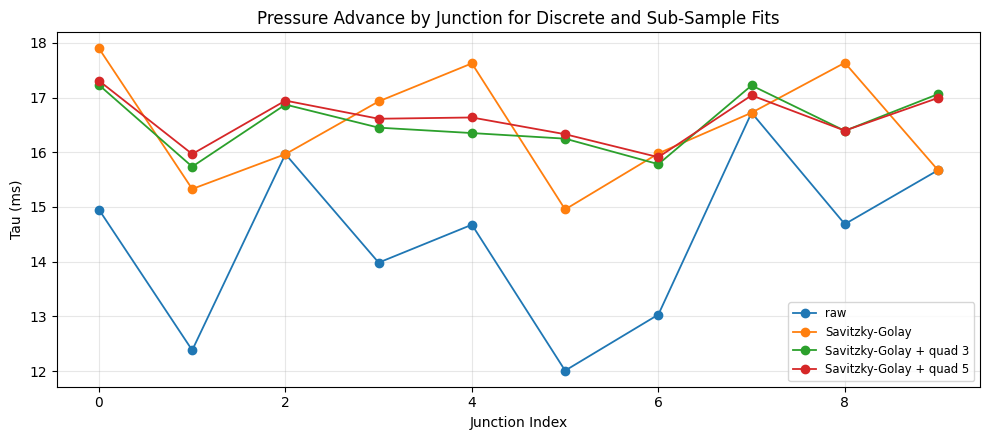

In [23]:
plot_tau_by_junction(
    fit_comparison,
    [
        ("raw", "raw_tau_ms"),
        ("Savitzky-Golay", "savgol_discrete_tau_ms"),
        ("Savitzky-Golay + quad 3", "savgol_quad3_tau_ms"),
        ("Savitzky-Golay + quad 5", "savgol_quad5_tau_ms"),
    ],
    plot_title="Pressure Advance by Junction for Discrete and Sub-Sample Fits",
)
plt.show()

## Notes

- The canonical input is a single JSON file containing `time`, `force`, `junctions`, and optional `fit_results` / `trapq_moves`.
- `time` is already relative to the start of the capture.
- The smoothing section below is offline-only, so it is useful for analysis but not representative of a causal real-time firmware filter.
- The zero-phase Butterworth pass is a good baseline for noise reduction, while the Savitzky-Golay pass is useful when you want to preserve the local trough shape for minimum picking.
- The filtered PA recompute intentionally mirrors the firmware analyzer's simple `argmin(force) - 1` reversal picker so the raw vs smoothed comparison stays apples-to-apples.
- A sensor delay correction is applied to every computed result by subtracting `SENSOR_DELAY_SAMPLES * sample_interval` from the fitted `tau` and event times.
- The 3-point fit is the most local estimate, while the 5-point fit is a slightly wider least-squares parabola that may be more robust to a noisy trough.
- The results table merges junction timing with any reported `fit_results` values present in the file.